<a href="https://colab.research.google.com/github/cedricguilmin/analytics_mining/blob/main/Image_compression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install skimpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 110.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykerne

In [ ]:
#inspired from
# https://medium.com/data-science/clear-and-visual-explanation-of-the-k-means-algorithm-applied-to-image-compression-b7fdc547e410
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load image using PIL
folder = '/content/drive/MyDrive/00_datamining/'
imagename = 'tutrle.jpg'
imagename = 'IMG_4200.jpeg'
image = Image.open(folder+imagename)  # Replace with your image path
img_array = np.array(image)
img_array.shape

(3024, 4032, 3)

In [ ]:
img_array.shape

(3024, 4032, 3)

In [ ]:
print(type(image), type(img_array))

<class 'PIL.JpegImagePlugin.JpegImageFile'> <class 'numpy.ndarray'>


In [ ]:
# Reshape to 2D array of pixels (rows) with RGB values (columns)
pixels = img_array.reshape((-1, 3))
pixels.shape

(12192768, 3)

In [ ]:
dfpixels = pd.DataFrame(pixels)
dfpixels.head()

,0,1,2
0,47,62,55
1,45,60,53
2,43,58,51
3,43,58,51
4,47,60,53


In [ ]:
dfpixels.drop_duplicates().shape

(367313, 3)

In [ ]:
from skimpy import skim
skim(dfpixels)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│           Data Summary                 Data Types                                                               │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                        │
│ ┃ Dataframe         ┃ Values   ┃ ┃ Column Type ┃ Count ┃                                                        │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                        │
│ │ Number of rows    │ 12192768 │ │ int64       │ 3     │                                                        │
│ │ Number of columns │ 3        │ └─────────────┴───────┘                                                        │
│ └───────────────────┴──────────┘                                                                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃ column      ┃ NA   ┃ NA %    ┃ mean      ┃ sd        ┃ p0   ┃ p25    ┃ p50    ┃ p75   ┃ p100    ┃ hist     ┃  │
│ ┡━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━┩  │
│ │           0 │    0 │       0 │     97.08 │     64.86 │    0 │     45 │     81 │   143 │     255 │  ▇█▅▄▃▂  │  │
│ │           1 │    0 │       0 │     107.4 │     62.26 │    0 │     57 │     97 │   151 │     255 │  ▅█▇▅▃▂  │  │
│ │           2 │    0 │       0 │     103.2 │      62.1 │    0 │     53 │     94 │   144 │     255 │  ▅█▇▅▃▂  │  │
│ └─────────────┴──────┴─────────┴───────────┴───────────┴──────┴────────┴────────┴───────┴─────────┴──────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [ ]:
img_array.shape[0] * img_array.shape[1] == pixels.shape[0]

True

In [ ]:
img_array.shape

(3024, 4032, 3)

In [ ]:
pixels.shape

(12192768, 3)

In [ ]:
# Piece of code to check if if is the same pixel at the same place between img_array and pixels
row, col = 0, 0

# Extract pixel from original image array
pixel_img_array = img_array[row, col]

# Calculate corresponding index in the reshaped pixels array
index_pixels = row * img_array.shape[1] + col
print("index_pixels:", index_pixels)
pixel_pixels = pixels[index_pixels]

# Check if they are equal
print("Pixel from img_array:", pixel_img_array)
print("Pixel from pixels:", pixel_pixels)
print("Are they equal?", np.array_equal(pixel_img_array, pixel_pixels))


index_pixels: 0
Pixel from img_array: [47 62 55]
Pixel from pixels: [47 62 55]
Are they equal? True


In [ ]:
nbr_cluster = 16

In [ ]:
# Perform K-means clustering
kmeans = KMeans(n_clusters=nbr_cluster, random_state=40, init='k-means++')
kmeans.fit(pixels)

KMeans(n_clusters=16, random_state=40)

In [ ]:
dir(kmeans)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_algorithm',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_mkl_vcomp',
 '_check_n_features',
 '_check_params_vs_input',
 '_check_test_data',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_init_centroids',
 '_more_tags',
 '_n_features_out',
 '_n_init',
 '_n_threads',
 '_parameter_constraints',
 '_re

In [ ]:
# check the maximum number of runs possible versus the number of runs done
print("Maximum number of runs: ", kmeans.max_iter)
print("Number of runs: ", kmeans.n_iter_)

Maximum number of runs:  300
Number of runs:  30


In [ ]:
kmeans.cluster_centers_

array([[ 52.71567144,  65.4548668 ,  62.59332161],
       [197.0467044 , 197.28161267, 185.86235529],
       [132.49232313, 136.61194716, 125.5267096 ],
       [250.29990359, 251.86094275, 249.9292931 ],
       [ 25.3021795 ,  33.46633592,  30.89225278],
       [110.48595585, 116.53035542, 108.39355952],
       [152.72210695, 156.65865836, 144.80545358],
       [ 91.00588626,  97.73580872,  91.07012474],
       [ 40.5396107 ,  49.24957076,  45.90202552],
       [139.01857333, 176.26951574, 203.82807504],
       [ 89.20159337, 134.04448576, 149.62175971],
       [ 53.49782654,  99.97763187, 106.44843147],
       [216.44781996, 220.35641153, 218.13536087],
       [175.06939288, 176.58095977, 162.59735217],
       [ 72.5136762 ,  79.8582904 ,  74.34304694],
       [ 10.61721115,  15.67348974,  13.66951239]])

In [ ]:
kmeans.labels_.shape

(12192768,)

In [ ]:
kmeans.labels_.max()

np.int32(15)

In [ ]:
# check number of unique value of labels for each pixel. Label = cluster number provided by kmeans
len(set(kmeans.labels_))

16

In [ ]:
print(kmeans.labels_.shape, kmeans.labels_[0])

(12192768,) 0


In [ ]:
print(kmeans.cluster_centers_.shape, kmeans.cluster_centers_[0])

(16, 3) [52.71567144 65.4548668  62.59332161]


In [ ]:
kmeans.cluster_centers_[np.array([0, 2,])]

array([[ 52.71567144,  65.4548668 ,  62.59332161],
       [132.49232313, 136.61194716, 125.5267096 ]])

In [ ]:
np.array([0.5,0.8,0.99]).astype(np.uint8)

array([0, 0, 0], dtype=uint8)

In [ ]:
np.array([0.5,0.8,0.99]).round().astype(np.uint8)

array([0, 1, 1], dtype=uint8)

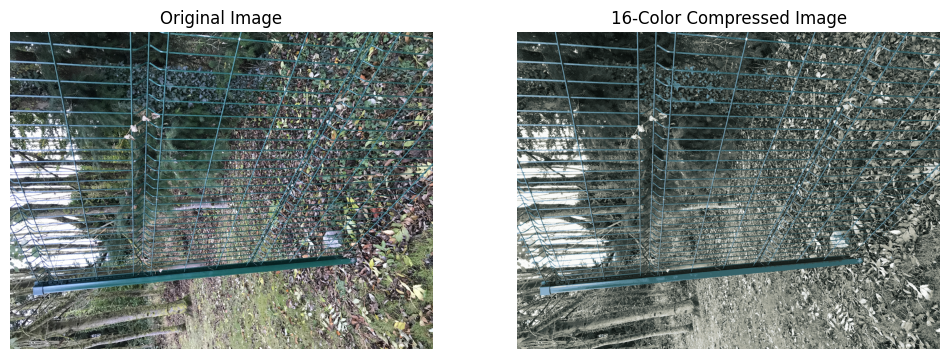

In [ ]:
# Create compressed image array
compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]
compressed_img = compressed_pixels.reshape(img_array.shape).astype(np.uint8)

# Create side-by-side comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(img_array)
ax1.set_title('Original Image')
ax1.axis('off')

ax2.imshow(compressed_img)
ax2.set_title(str(nbr_cluster)+'-Color Compressed Image')
ax2.axis('off')

plt.show()


In [ ]:
compressed_img.shape

(3024, 4032, 3)

In [ ]:
# https://www.techsmith.com/blog/jpg-vs-png/
original_image = Image.fromarray(img_array)
original_image.save(folder + 'original-' + imagename.replace('.jpeg', '.png'), format='PNG')

compressed_image = Image.fromarray(compressed_img)
compressed_image.save(folder + 'comp-' + imagename.replace('.jpeg', '.png'), format='PNG')